In [1]:
from pathlib import Path

from gofher.galaxy import Galaxy
from gofher.sparcfire import gofher_params_from_sparcfire_csv

In [2]:
bluer_to_redder_bands = ['g','r','i','z']
sparcfire_bulge_disk_f = 0.5

In [3]:
#IMPORTANT: Make sure these folder/file names reflect test file structure:
TEST_GALAXY_DIR = "NGC2347_SDSS_psf4_background_256"
TEST_SPARCFIRE_DIR = "sparcfire_r_band_output"
TEST_FITS_DIR = "fits"
TEST_CSV_FILE_NAME = "NGC2347_r.csv"

def _get_test_csv_path() -> str:
    p = Path("..").resolve()
    return str(p.joinpath("tests", "data", TEST_GALAXY_DIR, TEST_SPARCFIRE_DIR, TEST_CSV_FILE_NAME))

def _get_test_fits_path(band) -> str:
    """Helper function to get path to test fits file"""
    fits_file_name = f"NGC2347_{band}.fits"

    p = Path("..").resolve()
    return str(p.joinpath("tests", "data", TEST_GALAXY_DIR, TEST_FITS_DIR, fits_file_name))

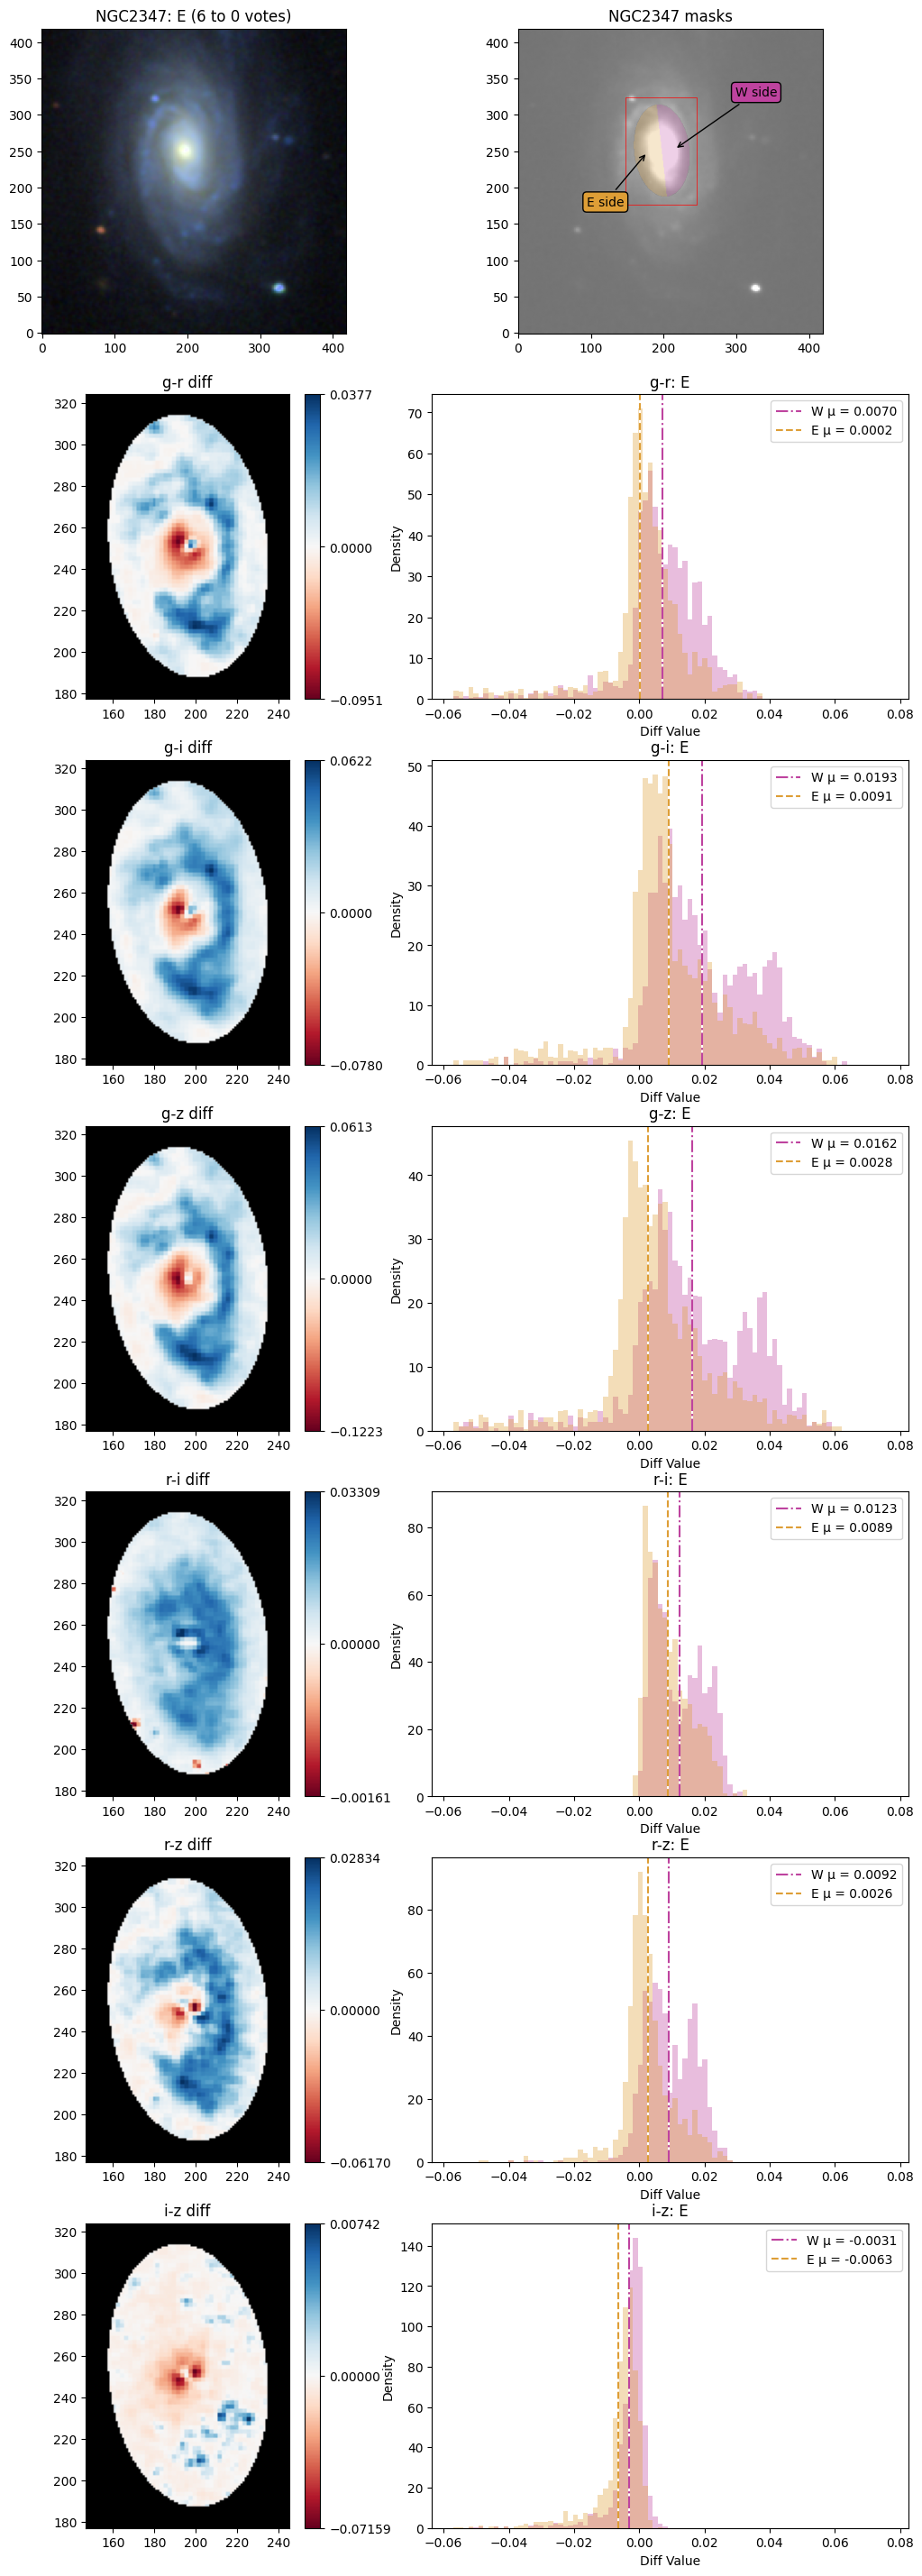

In [5]:
gofher_param = gofher_params_from_sparcfire_csv(_get_test_csv_path())[0]

the_galaxy = Galaxy(gofher_param)

for band in bluer_to_redder_bands:
    the_galaxy.construct_galaxy_band_from_fits(band,_get_test_fits_path(band))

the_galaxy.run(bluer_to_redder_bands=bluer_to_redder_bands,
               sparcfire_bulge_disk_f=sparcfire_bulge_disk_f,
               area_to_consider=None,
               fail_silently_on_missing_band=False)

the_galaxy.plot_figure()